# FIFA World Cup 2026 — Winner Prediction
## Notebook 03 — Model Training

The goal of this notebook is to train an XGBoost classifier to predict match outcomes, select the most predictive features, and evaluate model performance before passing the model to the simulation engine.

### Objectives
- Define feature set, identifiers, and targets from df_matches_features
- Explore correlations to remove redundant or irrelevant features
- Encode categorical variables
- Train XGBoost classifier
- Evaluate performance with classification report and confusion matrix
- Save model and feature list for use in notebook 04

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder

pd.set_option('display.max_columns', None)
plt.style.use('ggplot')

In [2]:
df = pd.read_csv("../data/processed/df_matches_features.csv")
print(df.shape)
df.head()

(418, 55)


,Tournament Id,Stage Name,Group Name,Group Stage,Knockout Stage,Match Date,Home Team Name,Away Team Name,Home Team Score,Away Team Score,Home Team Score Margin,Away Team Score Margin,Extra Time,Penalty Shootout,Score Penalties,Home Team Score Penalties,Away Team Score Penalties,Result,Home Team Win,Away Team Win,Draw,year,home_elo,home_rank,home_conf,home_is_host,home_elo_max,home_elo_avg,home_elo_min,home_wins,home_losses,home_draws,home_goals_for,home_goals_against,home_matches_total,away_elo,away_rank,away_conf,away_is_host,away_elo_max,away_elo_avg,away_elo_min,away_wins,away_losses,away_draws,away_goals_for,away_goals_against,away_matches_total,elo_diff,rank_diff,goal_diff,home_win_rate,away_win_rate,home_goals_per_match,away_goals_per_match
0,WC-1930,group stage,Group 1,1,0,1930-07-13,France,Mexico,4,1,3,-3,0,0,0-0,0,0,2,1,0,0,1930,1573,33,UEFA,0,1640,1572,1514,28,66,11,176,368,105,1498,40,CONCACAF,1,1708,1666,1498,4,6,1,21,33,11,75,-7,3,0.266667,0.363636,1.676190,1.909091
1,WC-1930,group stage,Group 4,1,0,1930-07-13,United States,Belgium,3,0,3,-3,0,0,0-0,0,0,2,1,0,0,1930,1761,14,CONCACAF,1,1784,1698,1671,7,7,2,38,42,16,1604,30,UEFA,0,1930,1772,1589,47,61,21,263,309,129,157,-16,3,0.437500,0.364341,2.375000,2.038760
2,WC-1930,group stage,Group 1,1,0,1930-07-15,Argentina,France,1,0,1,-1,0,0,0-0,0,0,2,1,0,0,1930,2060,1,CONMEBOL,0,2106,1975,1855,93,50,43,368,228,186,1573,33,UEFA,0,1640,1572,1514,28,66,11,176,368,105,487,-32,1,0.500000,0.266667,1.978495,1.676190
3,WC-1930,group stage,Group 4,1,0,1930-07-17,United States,Paraguay,3,0,3,-3,0,0,0-0,0,0,2,1,0,0,1930,1761,14,CONCACAF,1,1784,1698,1671,7,7,2,38,42,16,1737,16,CONMEBOL,0,1864,1738,1647,16,28,7,64,101,51,24,-2,3,0.437500,0.313725,2.375000,1.254902
4,WC-1930,group stage,Group 1,1,0,1930-07-19,Argentina,Mexico,6,3,3,-3,0,0,0-0,0,0,2,1,0,0,1930,2060,1,CONMEBOL,0,2106,1975,1855,93,50,43,368,228,186,1498,40,CONCACAF,1,1708,1666,1498,4,6,1,21,33,11,562,-39,3,0.500000,0.363636,1.978495,1.909091


## Column Audit — Features, Identifiers, and Targets

In [3]:
# Full column list for manual classification
for col in df.columns:
    print(col)

Tournament Id
Stage Name
Group Name
Group Stage
Knockout Stage
Match Date
Home Team Name
Away Team Name
Home Team Score
Away Team Score
Home Team Score Margin
Away Team Score Margin
Extra Time
Penalty Shootout
Score Penalties
Home Team Score Penalties
Away Team Score Penalties
Result
Home Team Win
Away Team Win
Draw
year
home_elo
home_rank
home_conf
home_is_host
home_elo_max
home_elo_avg
home_elo_min
home_wins
home_losses
home_draws
home_goals_for
home_goals_against
home_matches_total
away_elo
away_rank
away_conf
away_is_host
away_elo_max
away_elo_avg
away_elo_min
away_wins
away_losses
away_draws
away_goals_for
away_goals_against
away_matches_total
elo_diff
rank_diff
goal_diff
home_win_rate
away_win_rate
home_goals_per_match
away_goals_per_match


In [4]:
identifier_cols = [
    'Tournament Id', 'Stage Name', 'Group Name', 'Group Stage',
    'Knockout Stage', 'Match Date', 'Home Team Name', 'Away Team Name',
    'year'
]

target_cols = [
    'Result',           # 3-class: 0=away win, 1=draw, 2=home win
    'Home Team Win',    # binary
    'Away Team Win',    # binary
    'Draw'              # binary
]

# Remaining score/outcome columns — not features, not targets
score_cols = [
    'Home Team Score', 'Away Team Score',
    'Home Team Score Margin', 'Away Team Score Margin',
    'Extra Time', 'Penalty Shootout', 'Score Penalties',
    'Home Team Score Penalties', 'Away Team Score Penalties',
    'goal_diff'         # computed from score — would be data leakage
]

feature_cols = [col for col in df.columns
                if col not in identifier_cols + target_cols + score_cols]

print(f"Identifiers : {len(identifier_cols)}")
print(f"Targets     : {len(target_cols)}")
print(f"Score/leak  : {len(score_cols)}")
print(f"Features    : {len(feature_cols)}")
print()
print(feature_cols)

Identifiers : 9
Targets     : 4
Score/leak  : 10
Features    : 32

['home_elo', 'home_rank', 'home_conf', 'home_is_host', 'home_elo_max', 'home_elo_avg', 'home_elo_min', 'home_wins', 'home_losses', 'home_draws', 'home_goals_for', 'home_goals_against', 'home_matches_total', 'away_elo', 'away_rank', 'away_conf', 'away_is_host', 'away_elo_max', 'away_elo_avg', 'away_elo_min', 'away_wins', 'away_losses', 'away_draws', 'away_goals_for', 'away_goals_against', 'away_matches_total', 'elo_diff', 'rank_diff', 'home_win_rate', 'away_win_rate', 'home_goals_per_match', 'away_goals_per_match']


## Correlation Analysis
### 1 — Feature-to-feature heatmap (multicollinearity)

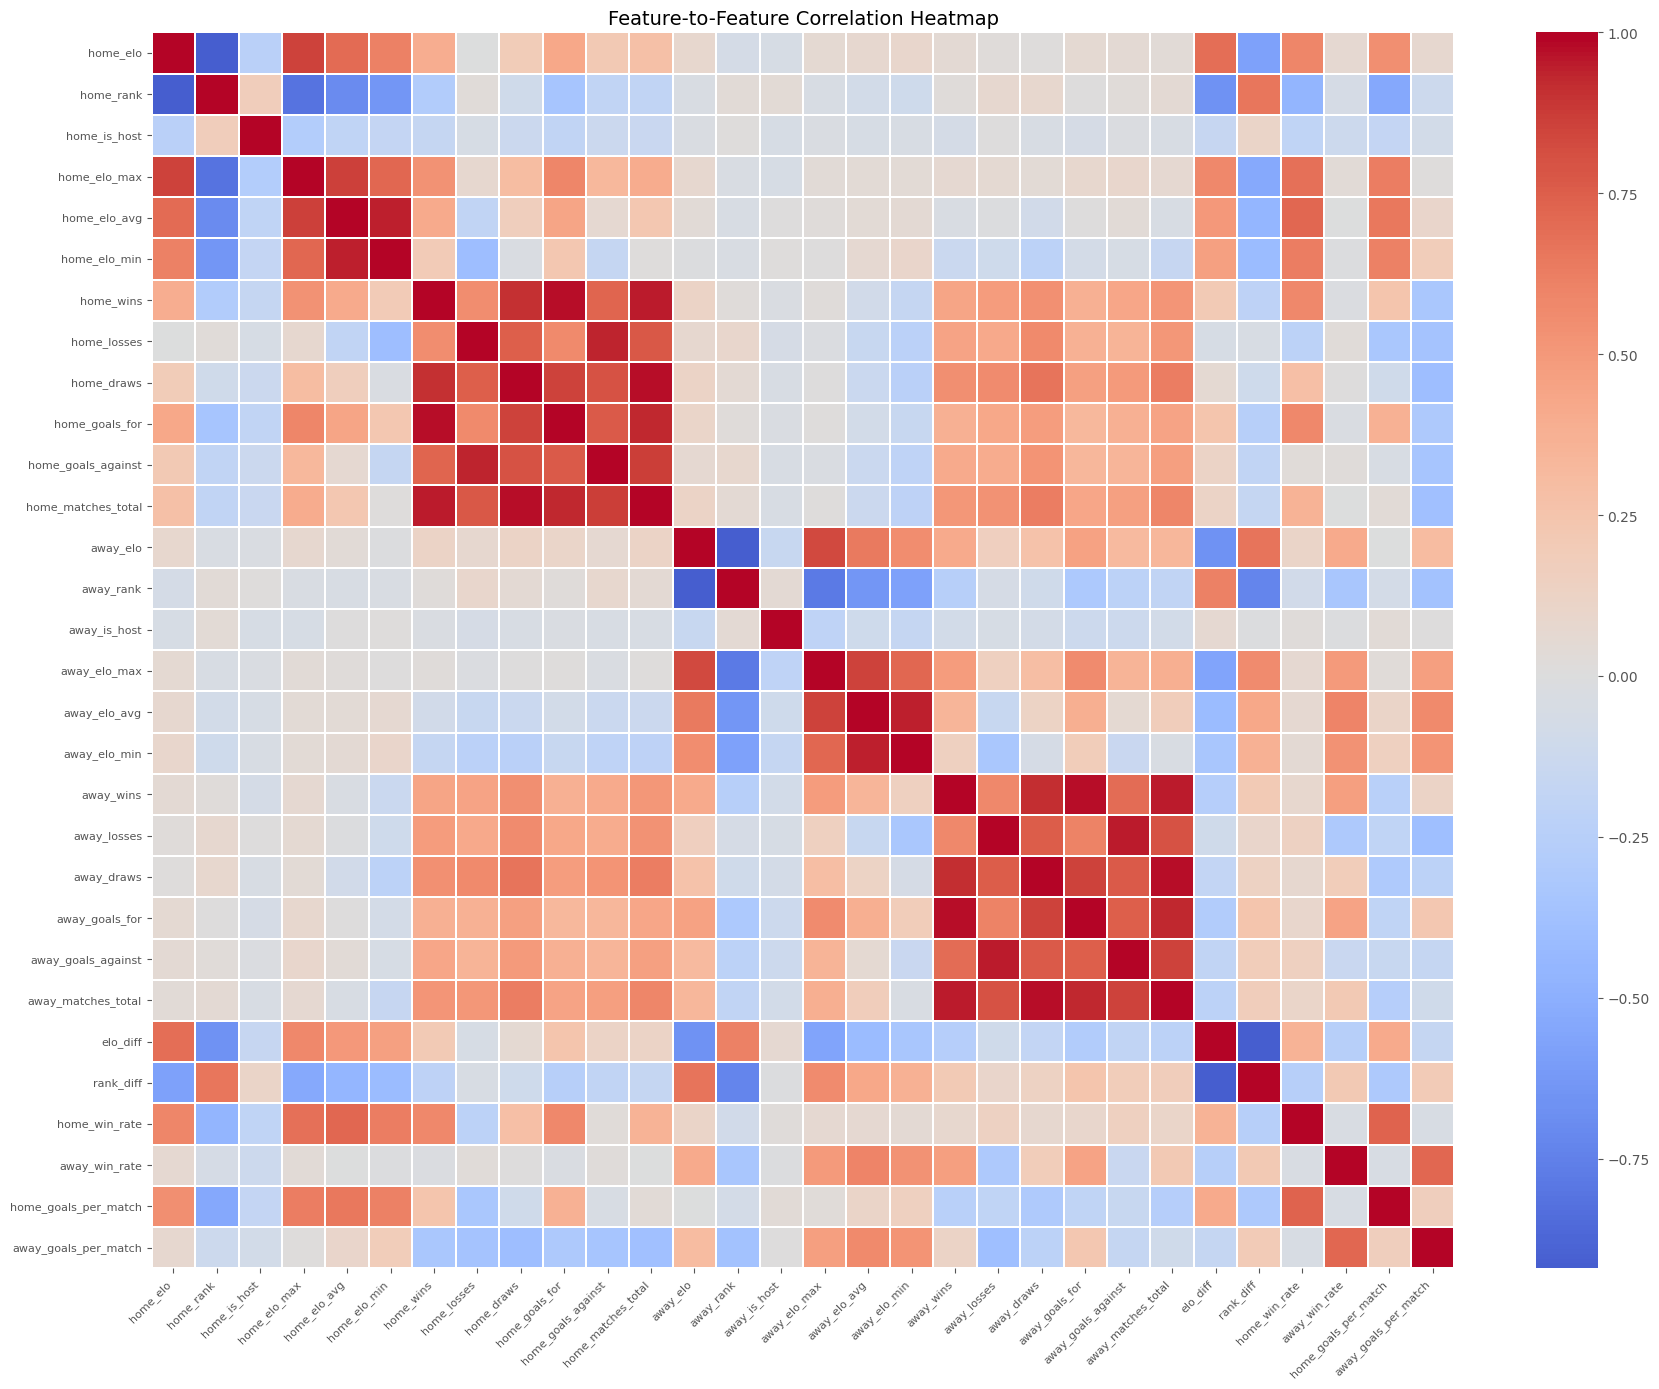

In [5]:
df_features = df[feature_cols].copy()

# Keep only numeric columns for correlation
numeric_features = df_features.select_dtypes(include=[np.number]).columns.tolist()

corr_matrix = df_features[numeric_features].corr()

plt.figure(figsize=(18, 14))
sns.heatmap(
    corr_matrix,
    annot=False,
    cmap='coolwarm',
    center=0,
    linewidths=0.3,
    linecolor='white'
)
plt.title("Feature-to-Feature Correlation Heatmap", fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

### 2 — Feature correlation with target (Home Team Win)

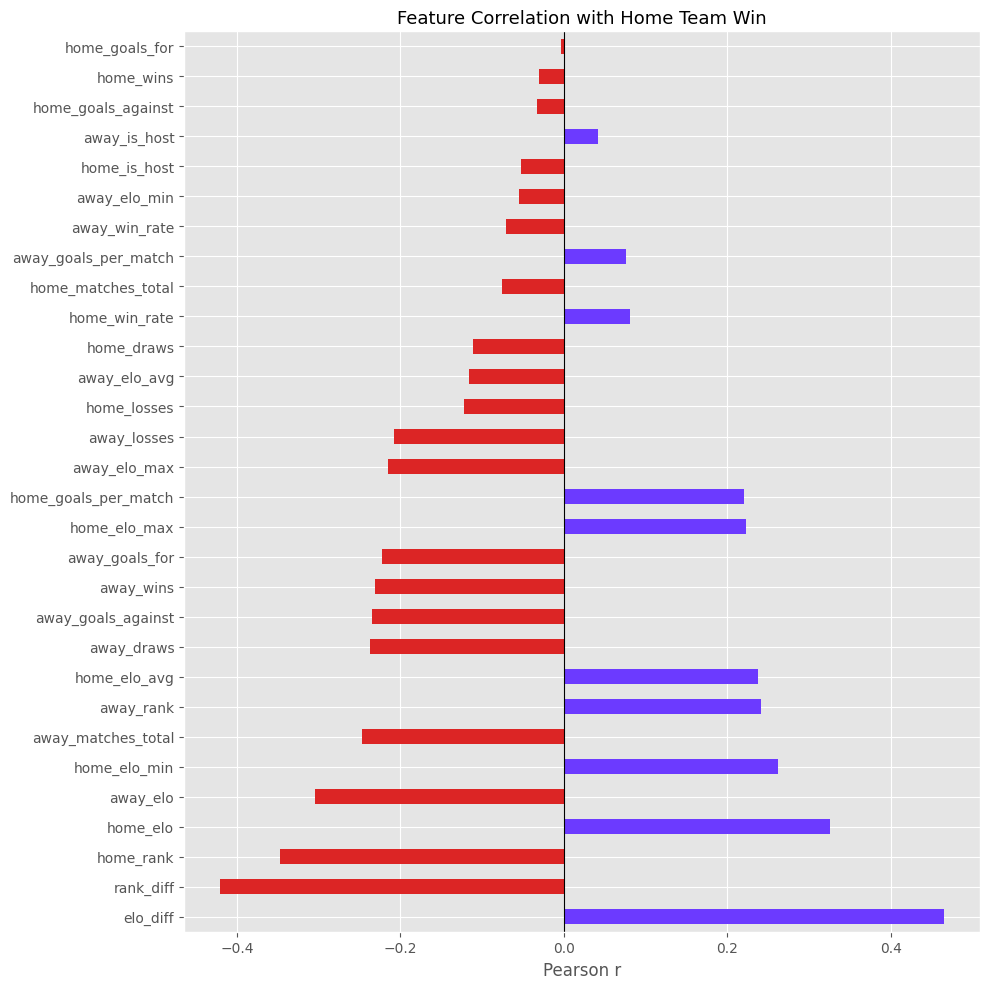

elo_diff                0.464822
rank_diff              -0.420377
home_rank              -0.347889
home_elo                0.325609
away_elo               -0.304075
home_elo_min            0.261394
away_matches_total     -0.247168
away_rank               0.240948
home_elo_avg            0.237506
away_draws             -0.236669
away_goals_against     -0.234197
away_wins              -0.231005
away_goals_for         -0.222553
home_elo_max            0.222501
home_goals_per_match    0.220790
away_elo_max           -0.214732
away_losses            -0.208248
home_losses            -0.122101
away_elo_avg           -0.116102
home_draws             -0.111194
home_win_rate           0.081381
home_matches_total     -0.076237
away_goals_per_match    0.075900
away_win_rate          -0.070247
away_elo_min           -0.054551
home_is_host           -0.052861
away_is_host            0.042132
home_goals_against     -0.032314
home_wins              -0.029871
home_goals_for         -0.004033


In [6]:
df_corr_target = df[numeric_features + ['Home Team Win']].copy()

target_corr = (
    df_corr_target.corr()['Home Team Win']
    .drop('Home Team Win')
    .sort_values(key=abs, ascending=False)
)

plt.figure(figsize=(10, 10))
target_corr.plot(
    kind='barh',
    color=target_corr.map(lambda x: '#6C3AFF' if x >= 0 else '#DC2525')
)
plt.axvline(0, color='black', linewidth=0.8)
plt.title("Feature Correlation with Home Team Win", fontsize=13)
plt.xlabel("Pearson r")
plt.tight_layout()
plt.show()

print(target_corr.to_string())

## Feature Selection

Drop features with:
- Near-zero correlation with target (|r| < 0.05)
- High multicollinearity with a stronger feature (|r| > 0.90 between features)

Keep the stronger of each correlated pair (higher |r| with target).

In [7]:
# Features with |r| < 0.05 with Home Team Win
low_signal = target_corr[abs(target_corr) < 0.05].index.tolist()
print("Low signal features:", low_signal)

# Highly correlated pairs (|r| > 0.90)
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.90:
            high_corr_pairs.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                round(corr_matrix.iloc[i, j], 3)
            ))

print("\nHighly correlated pairs (|r| > 0.90):")
for a, b, r in high_corr_pairs:
    # Keep the one with higher absolute correlation with target
    keep = a if abs(target_corr.get(a, 0)) >= abs(target_corr.get(b, 0)) else b
    drop = b if keep == a else a
    print(f"  {a} vs {b} → r={r} | keep: {keep}, drop: {drop}")

Low signal features: ['away_is_host', 'home_goals_against', 'home_wins', 'home_goals_for']

Highly correlated pairs (|r| > 0.90):
  home_elo vs home_rank → r=-0.917 | keep: home_rank, drop: home_elo
  home_elo_avg vs home_elo_min → r=0.944 | keep: home_elo_min, drop: home_elo_avg
  home_wins vs home_draws → r=0.906 | keep: home_draws, drop: home_wins
  home_wins vs home_goals_for → r=0.976 | keep: home_wins, drop: home_goals_for
  home_wins vs home_matches_total → r=0.955 | keep: home_matches_total, drop: home_wins
  home_losses vs home_goals_against → r=0.936 | keep: home_losses, drop: home_goals_against
  home_draws vs home_matches_total → r=0.973 | keep: home_draws, drop: home_matches_total
  home_goals_for vs home_matches_total → r=0.931 | keep: home_matches_total, drop: home_goals_for
  away_elo vs away_rank → r=-0.914 | keep: away_elo, drop: away_rank
  away_elo_avg vs away_elo_min → r=0.944 | keep: away_elo_avg, drop: away_elo_min
  away_wins vs away_draws → r=0.914 | keep: away

In [8]:
# Drop low-signal features (|r| < 0.05 with target) and highly correlated redundant features
cols_to_drop = [
    # Near-zero correlation with target
    'home_goals_for',
    'home_wins',
    'home_goals_against',
    'away_is_host',
    'home_is_host',

    # High multicollinearity — weaker than elo_diff / rank_diff
    'home_elo_max',
    'home_elo_avg',
    'home_elo_min',
    'away_elo_max',
    'away_elo_avg',

    # Redundant with win_rate and goals_per_match
    'home_losses',
    'home_draws',
    'away_wins',
    'away_losses',
    'away_draws',
    'away_goals_for',
    'away_goals_against',
    'home_matches_total',
    'away_matches_total',
]

cols_to_drop = list(set(cols_to_drop))

final_features = [col for col in numeric_features if col not in cols_to_drop]

print(f"Final feature count: {len(final_features)}")
print(final_features)

Final feature count: 11
['home_elo', 'home_rank', 'away_elo', 'away_rank', 'away_elo_min', 'elo_diff', 'rank_diff', 'home_win_rate', 'away_win_rate', 'home_goals_per_match', 'away_goals_per_match']


## Categorical Encoding

`home_conf` and `away_conf` are the only categorical features. Using `LabelEncoder` — XGBoost handles ordinal-encoded categoricals natively and doesn't require one-hot encoding.

In [9]:
le = LabelEncoder()

df['home_conf_enc'] = le.fit_transform(df['home_conf'].astype(str))
df['away_conf_enc'] = le.fit_transform(df['away_conf'].astype(str))

# Add encoded columns to final features if not already included
for col in ['home_conf_enc', 'away_conf_enc']:
    if col not in final_features:
        final_features.append(col)

print("Confederation classes:", le.classes_)
print("Final feature count:", len(final_features))

Confederation classes: ['AFC' 'CAF' 'CONCACAF' 'CONMEBOL' 'OFC' 'UEFA']
Final feature count: 13


## Model Training

- Target: `Result` (3-class: 0=away win, 1=draw, 2=home win)                                    CAMBIAR
- Handling class imbalance with `scale_pos_weight` via `sample_weight`
- 80/20 train-test split, stratified by target

In [10]:
# Collapse to binary target: 1 = Home Win, 0 = No Home Win (draw or away win)
# Draws in knockout rounds are resolved via Elo-weighted penalty probability in simulation
df['result_binary'] = (df['Result'] == 2).astype(int)

print("Binary target distribution:")
print(df['result_binary'].value_counts())
print(f"\nClass balance: {df['result_binary'].mean():.2%} home wins")

Binary target distribution:
result_binary
1    227
0    191
Name: count, dtype: int64

Class balance: 54.31% home wins


In [11]:
X = df[final_features].copy()
y = df['result_binary'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Class distribution:\n{y_train.value_counts()}")

Train: (334, 13), Test: (84, 13)
Class distribution:
result_binary
1    181
0    153
Name: count, dtype: int64


In [12]:
from sklearn.utils.class_weight import compute_sample_weight

model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

model.fit(
    X_train, y_train,
    sample_weight=sample_weights,
    eval_set=[(X_test, y_test)],
    verbose=50
)

[0]	validation_0-logloss:0.68316
[50]	validation_0-logloss:0.58065
[100]	validation_0-logloss:0.60298
[150]	validation_0-logloss:0.62595


/Users/gianmarcoassandria/Desktop/Proyectos_DS/wc2026-predictor/wc2026-predictor/.venv/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [11:20:48] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[200]	validation_0-logloss:0.64774
[250]	validation_0-logloss:0.68015
[299]	validation_0-logloss:0.70045


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


## Evaluation

In [15]:
y_pred = model.predict(X_test)

In [16]:
print(classification_report(
    y_test, y_pred,
    target_names=['No Home Win', 'Home Win']
))

              precision    recall  f1-score   support

 No Home Win       0.68      0.71      0.69        38
    Home Win       0.75      0.72      0.73        46

    accuracy                           0.71        84
   macro avg       0.71      0.71      0.71        84
weighted avg       0.72      0.71      0.71        84



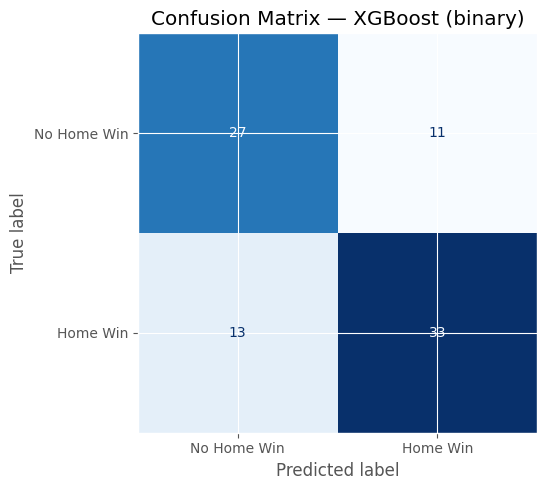

In [18]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['No Home Win', 'Home Win'])

fig, ax = plt.subplots(figsize=(7, 5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title("Confusion Matrix — XGBoost (binary)")
plt.tight_layout()
plt.show()

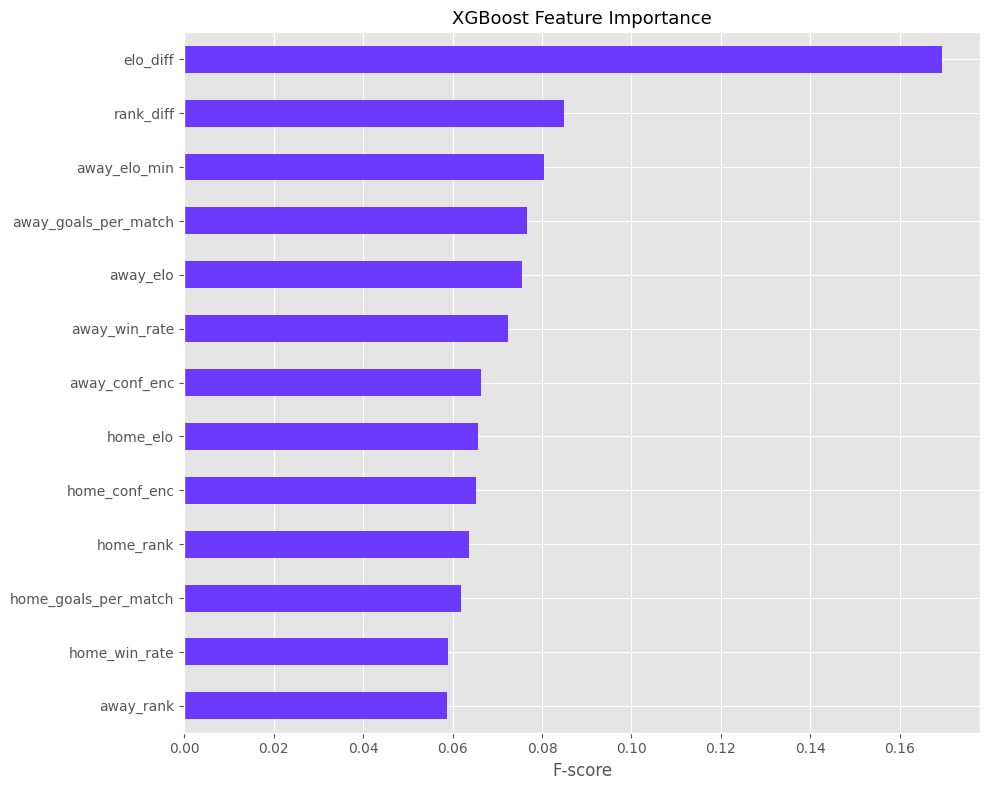

In [21]:
importances = pd.Series(model.feature_importances_, index=final_features)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(10, 8))
importances.plot(kind='barh', color='#6C3AFF')
plt.title("XGBoost Feature Importance", fontsize=13)
plt.xlabel("F-score")
plt.tight_layout()
plt.show()

## Save Model and Feature List

In [22]:
import joblib
import json
import os

os.makedirs("../models", exist_ok=True)

# Save model
joblib.dump(model, "../models/xgb_match_predictor.pkl")

# Save feature list
with open("../models/feature_list.json", "w") as f:
    json.dump(final_features, f)

print("Model saved → models/xgb_match_predictor.pkl")
print("Feature list saved → models/feature_list.json")

Model saved → models/xgb_match_predictor.pkl
Feature list saved → models/feature_list.json
